<a href="https://colab.research.google.com/github/BeastHunter0041/csci_4170_s26/blob/main/03_sequential_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [30]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["Month"])
df["y"] = df["Passengers"]

df = df[["date", "y"]].copy()
df.head()

,date,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [31]:
print(test_df.columns)

Index(['Month', 'y', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12'], dtype='object')


## Dataset setup

For this checkpoint, I use the Airline Passengers dataset.  
It contains the number of international airline passengers from 1949 to 1960.


##Quick data visualization

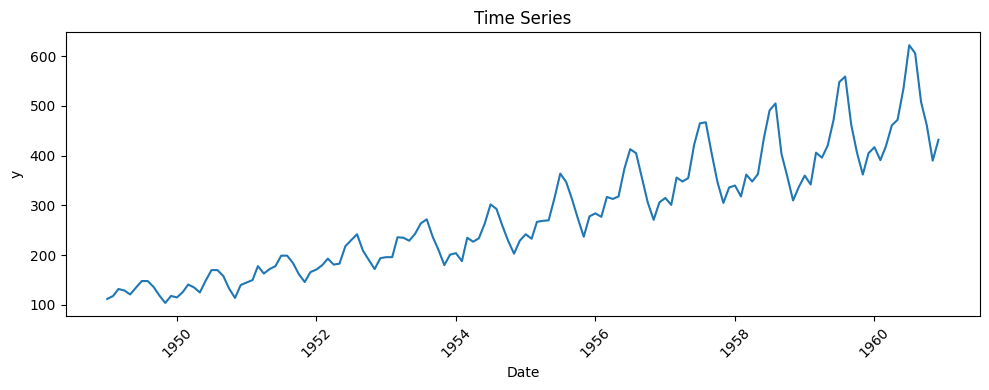

In [32]:
plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["y"])
plt.title("Time Series")
plt.xlabel("Date")
plt.ylabel("y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Lag feature construction

To let the regression model use past information, I create lag features.  
Each lag column stores an earlier value of the series, so the model can learn how recent history predicts the next observation.

In [33]:
for lag in [1, 2, 3, 6, 12]:
    df[f"lag_{lag}"] = df["y"].shift(lag)

df.head(15)

,date,y,lag_1,lag_2,lag_3,lag_6,lag_12
0,1949-01-01,112,NaN,NaN,NaN,NaN,NaN
1,1949-02-01,118,112.0,NaN,NaN,NaN,NaN
2,1949-03-01,132,118.0,112.0,NaN,NaN,NaN
3,1949-04-01,129,132.0,118.0,112.0,NaN,NaN
4,1949-05-01,121,129.0,132.0,118.0,NaN,NaN
5,1949-06-01,135,121.0,129.0,132.0,NaN,NaN
6,1949-07-01,148,135.0,121.0,129.0,112.0,NaN
7,1949-08-01,148,148.0,135.0,121.0,118.0,NaN
8,1949-09-01,136,148.0,148.0,135.0,132.0,NaN
9,1949-10-01,119,136.0,148.0,148.0,129.0,NaN


## Drop missing rows caused by lagging


In [34]:
df_model = df.dropna().copy()
df_model.head()

,date,y,lag_1,lag_2,lag_3,lag_6,lag_12
12,1950-01-01,115,118.0,104.0,119.0,148.0,112.0
13,1950-02-01,126,115.0,118.0,104.0,148.0,118.0
14,1950-03-01,141,126.0,115.0,118.0,136.0,132.0
15,1950-04-01,135,141.0,126.0,115.0,119.0,129.0
16,1950-05-01,125,135.0,141.0,126.0,104.0,121.0


## Time-aware train/test split

A forecasting task must preserve chronology, so I do not randomly shuffle the data.  
Instead, I use the earlier part of the series for training and the later part for testing.

In [35]:
feature_cols = ["lag_1", "lag_2", "lag_3", "lag_6", "lag_12"]

split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df["y"]

X_test = test_df[feature_cols]
y_test = test_df["y"]

print("Train size:", len(train_df))
print("Test size :", len(test_df))

Train size: 105
Test size : 27


## Baseline model: last-value forecast

The baseline predicts the next value using the most recent observation only.  
This is a strong simple baseline for many time-series problems because nearby values are often similar.

In [36]:
baseline_pred = test_df["lag_1"].values
baseline_pred[:5]

array([404., 359., 310., 337., 360.])

## Stronger model: linear regression on lag features

The stronger model uses multiple lagged values instead of only the last one.  
This can help the model capture short-term structure and some seasonal behavior more effectively than the naïve baseline.

In [37]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_pred[:5]

array([380.15813442, 344.30546848, 354.62134892, 367.54452525,
       348.36273885])

## Evaluation metrics

I use:
- MAE: average absolute forecast error
- RMSE: square-root of average squared error

Lower values indicate better forecasting performance.

In [38]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = pd.DataFrame({
    "Model": ["Last Value Baseline", "Linear Regression (Lag Features)"],
    "MAE": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, lr_pred)
    ],
    "RMSE": [
        rmse(y_test, baseline_pred),
        rmse(y_test, lr_pred)
    ]
})

results

,Model,MAE,RMSE
0,Last Value Baseline,43.777778,50.738254
1,Linear Regression (Lag Features),15.068845,18.342887


## Forecast plot on the held-out period

The plot below compares:
- the true values in the test period
- the baseline forecast
- the stronger regression forecast

This makes the difference between the two approaches visually clear.

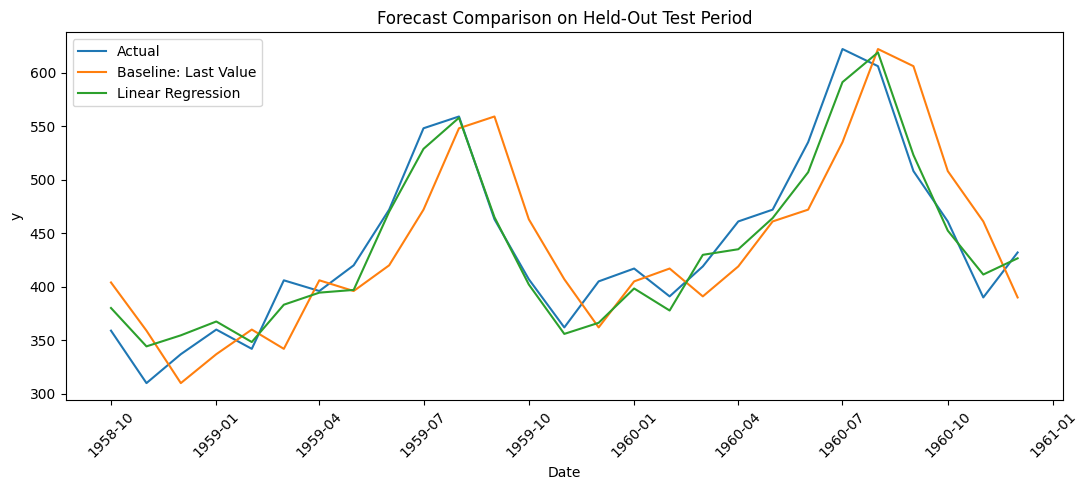

In [40]:
plt.figure(figsize=(11, 5))
plt.plot(test_df["date"], y_test.values, label="Actual")
plt.plot(test_df["date"], baseline_pred, label="Baseline: Last Value")
plt.plot(test_df["date"], lr_pred, label="Linear Regression")
plt.title("Forecast Comparison on Held-Out Test Period")
plt.xlabel("Date")
plt.ylabel("y")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Brief interpretation

The linear regression model using lag features performed much better than the last-value baseline on the Airline Passengers dataset. It achieved a much lower MAE (15.07 vs. 43.78) and RMSE (18.34 vs. 50.74), showing that using several past observations gave much more accurate forecasts than relying only on the previous month. In the forecast plot, the baseline often lagged behind the true series and missed the shape of the seasonal pattern, while the linear regression model tracked the rises and falls more closely. This makes sense because the dataset has a strong upward trend and clear seasonality, so a model with multiple lag inputs can use more of that structure.

## Where the stronger model helps

The stronger model helps when the series has repeating seasonal behavior and depends on more than just the most recent value. In this dataset, passenger counts rise and fall in a regular yearly pattern while also increasing over time, and the lag-feature regression model captures that structure much better than the baseline. It is especially helpful around the larger seasonal swings, where using lags such as 6 and 12 months gives the model useful context from earlier parts of the cycle.

## Where the stronger model still struggles

The stronger model still struggles to match some of the highest peaks and sharpest month-to-month changes perfectly. Although it follows the general pattern well, it can still slightly underpredict or overpredict during periods where the growth and seasonal amplitude become especially large near the end of the series. This happens because a simple linear regression on fixed lag features is still limited and may not fully capture increasingly strong seasonal effects or more complex nonlinear behavior.